# Tarea Práctica: Evaluación Comparativa de Modelos Supervisados

**Objetivo:** Aplicar y comparar diversos algoritmos de clasificación y regresión, analizando el impacto del preprocesamiento (normalización/escalado) sobre su desempeño.

---

## Instrucciones


1. **Datasets**:
   - **Clasificación**: `load_wine` (scikit-learn).
   - **Regresión**: `load_diabetes` (scikit-learn).

2. **División**: Cada dataset se divide en entrenamiento (80 %) y prueba (20 %) con `train_test_split`.

3. **Dos versiones de datos**: Para cada dataset existen:
   - Versión **original** (sin transformar).
   - Versión **normalizada** (usando `StandardScaler`).

4. **Para cada algoritmo** se pide:
   1. Importar el modelo.
   2. Instanciarlo modificando hiperparámetros relevantes.
   3. **Decidir** si se entrena con datos originales o normalizados, justificando.
   4. Entrenar, predecir y reportar métricas.

5. **Métricas**:
   - **Clasificación**: Accuracy + Matriz de Confusión.
   - **Regresión**: MSE + R².

> **Nota**: Las funciones de evaluación ya están implementadas más abajo. Solo necesitan llamarlas con el modelo, los datos de prueba y el tipo de tarea.

---
## 1. Preparación de datos

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

### 1.1 Dataset de clasificación — Wine

Dataset Wine
Muestras: 178, Features: 13, Clases: [0 1 2]


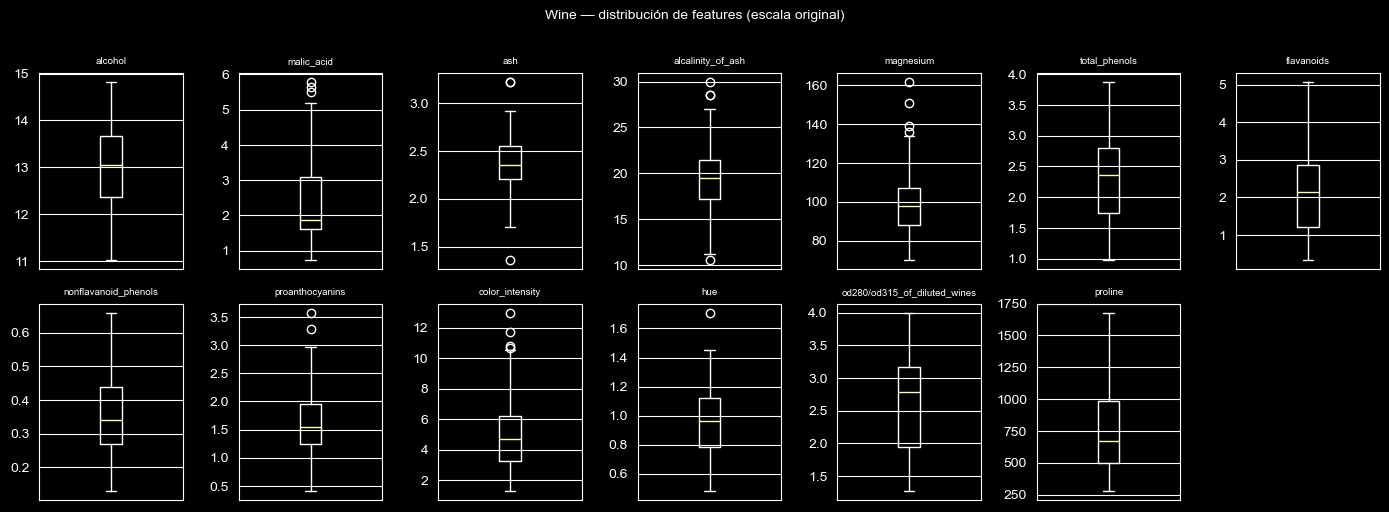

In [3]:
from sklearn.datasets import load_wine

data_clf = load_wine()
X_clf, y_clf = data_clf.data, data_clf.target

print(f"Dataset Wine")
print(f"Muestras: {X_clf.shape[0]}, Features: {X_clf.shape[1]}, Clases: {np.unique(y_clf)}")

# Distribución de características
plt.figure(figsize=(14, 5))
for i in range(X_clf.shape[1]):
    plt.subplot(2, 7, i + 1)
    plt.boxplot(X_clf[:, i])
    plt.title(data_clf.feature_names[i], fontsize=7)
    plt.xticks([])
plt.suptitle('Wine — distribución de features (escala original)', fontsize=10, y=1.01)
plt.tight_layout()
plt.show()

In [4]:
X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

scaler_clf = StandardScaler()
X_clf_train_scaled = scaler_clf.fit_transform(X_clf_train)
X_clf_test_scaled  = scaler_clf.transform(X_clf_test)

print(f"Train: {X_clf_train.shape[0]} | Test: {X_clf_test.shape[0]}")

Train: 142 | Test: 36


### 1.2 Dataset de regresión — Diabetes

Dataset Diabetes
Muestras: 442, Features: 10


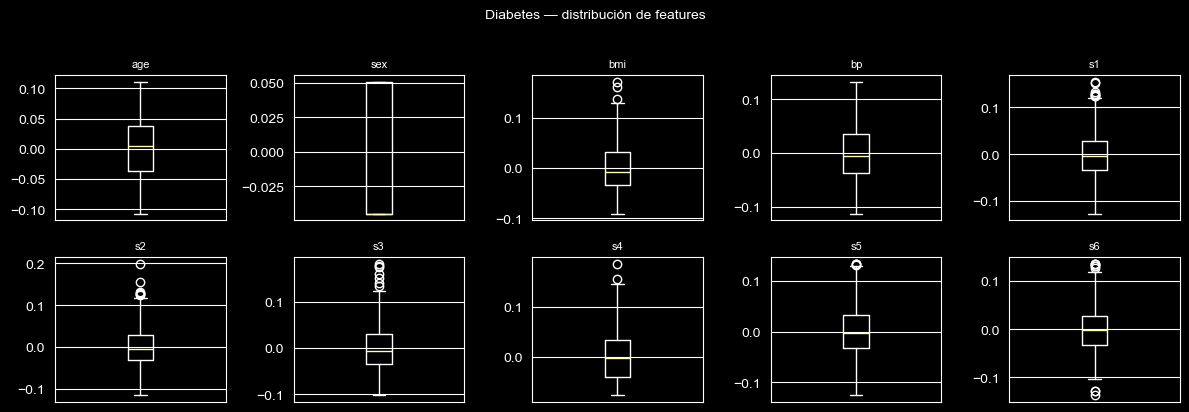

In [5]:
from sklearn.datasets import load_diabetes

# Nota: el notebook base importaba fetch_california_housing pero el enunciado indicaba load_diabetes; usamos load_diabetes.
data_reg = load_diabetes()
X_reg, y_reg = data_reg.data, data_reg.target

print(f"Dataset Diabetes")
print(f"Muestras: {X_reg.shape[0]}, Features: {X_reg.shape[1]}")

# Plot distribución de las características usando boxplots
plt.figure(figsize=(12, 4))
for i in range(X_reg.shape[1]):
    plt.subplot(2, 5, i + 1)
    plt.boxplot(X_reg[:, i])
    plt.title(data_reg.feature_names[i], fontsize=8)
    plt.xticks([])
plt.suptitle('Diabetes — distribución de features', fontsize=10, y=1.02)
plt.tight_layout()
plt.show()

In [6]:
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

scaler_reg = StandardScaler()
X_reg_train_scaled = scaler_reg.fit_transform(X_reg_train)
X_reg_test_scaled  = scaler_reg.transform(X_reg_test)

print(f"Train: {X_reg_train.shape[0]} | Test: {X_reg_test.shape[0]}")

Train: 353 | Test: 89


---
## 2. Funciones de evaluación (proporcionadas)

In [7]:
from sklearn.metrics import (
    accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
    mean_squared_error, r2_score
)

def evaluar_clasificacion(modelo, X_test, y_test, nombre_modelo="Modelo"):
    y_pred = modelo.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    cm  = confusion_matrix(y_test, y_pred)
    print(f"{'='*50}")
    print(f" {nombre_modelo} — Clasificación")
    print(f"{'='*50}")
    print(f" Accuracy: {acc:.4f}\n")
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(cm).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Matriz de Confusión — {nombre_modelo}')
    plt.tight_layout(); plt.show()
    return acc

def evaluar_regresion(modelo, X_test, y_test, nombre_modelo='Modelo'):
    y_pred = modelo.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2  = r2_score(y_test, y_pred)
    print(f"{'='*50}")
    print(f" {nombre_modelo} — Regresión")
    print(f"{'='*50}")
    print(f" MSE : {mse:.4f}")
    print(f" R²  : {r2:.4f}\n")
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.scatter(y_test, y_pred, alpha=0.6, edgecolors='k', linewidths=0.5)
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, '--', color='gray', linewidth=1)
    ax.set_xlabel('Valor real'); ax.set_ylabel('Predicción')
    ax.set_title(f'Real vs. Predicho — {nombre_modelo}')
    plt.tight_layout(); plt.show()
    return mse, r2

---
# Parte A: Clasificación (Dataset: Wine)

En esta sección aplicamos todos los métodos de **clasificación** sobre el dataset Wine.

---
## 3. Linear Discriminant Analysis (LDA)

**Instrucciones**: Importar → Instanciar → Decidir datos (justificar) → Evaluar.

### Observaciones:
- LDA sin shrinkage es invariante al escalado, obtenemos el mismo accuracy (0.9444) con datos originales y escalados.
- Con shrinkage='auto' (Ledoit-Wolf), LDA sigue siendo invariante y mejora a 1.0000 en ambos casos, porque 'auto' estima el parámetro de regularización y se adapta a la escala de los datos.
- Con shrinkage fijo (0.1 o 0.5), LDA si depende de la escala, sin escalado el accuracy cae a 0.7778, pero con escalado alcanza 1.0000. Esto se debe a que el shrinkage penaliza en función de la magnitud de la covarianza, y sin escalar las features de mayor varianza (proline) reciben una penalización desproporcionada, y esto degrada el modelo.
- El parametro n_components no impacta el accuracy, con 1 o 2 componentes el resultado es idéntico, porque la primera dimensión discriminante ya separa perfectamente las 3 clases.
- Mejor resultado: solver='lsqr' o 'eigen' con shrinkage='auto' → 1.0000, tanto con datos originales como escalados.

In [32]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score

# Experimento, comparar solver, n_components, shrinkage y escalado
configuraciones = [
    ('svd',   None,   [None]),
    ('lsqr',  None,   [None, 'auto', 0.1, 0.5]),
    ('eigen', None,   [None, 'auto', 0.1, 0.5]),
]

print(f"{'solver':<8} | {'n_components':<13} | {'shrinkage':<10} | {'original':>9} | {'escalado':>9}")
print("-" * 60)
for solver, _, shrinkages in configuraciones:
    for shrink in shrinkages:
        for n_comp in [1, 2]:
            m_orig = LinearDiscriminantAnalysis(solver=solver, n_components=n_comp, shrinkage=shrink)
            m_orig.fit(X_clf_train, y_clf_train)
            acc_o = accuracy_score(y_clf_test, m_orig.predict(X_clf_test))

            m_scal = LinearDiscriminantAnalysis(solver=solver, n_components=n_comp, shrinkage=shrink)
            m_scal.fit(X_clf_train_scaled, y_clf_train)
            acc_s = accuracy_score(y_clf_test, m_scal.predict(X_clf_test_scaled))

            shrink_str = str(shrink) if shrink is not None else 'None'
            print(f"{solver:<8} | n={n_comp:<11} | {shrink_str:<10} | {acc_o:.4f}    | {acc_s:.4f}")



solver   | n_components  | shrinkage  |  original |  escalado
------------------------------------------------------------
svd      | n=1           | None       | 0.9444    | 0.9444
svd      | n=2           | None       | 0.9444    | 0.9444
lsqr     | n=1           | None       | 0.9444    | 0.9444
lsqr     | n=2           | None       | 0.9444    | 0.9444
lsqr     | n=1           | auto       | 1.0000    | 1.0000
lsqr     | n=2           | auto       | 1.0000    | 1.0000
lsqr     | n=1           | 0.1        | 0.7778    | 1.0000
lsqr     | n=2           | 0.1        | 0.7778    | 1.0000
lsqr     | n=1           | 0.5        | 0.7778    | 1.0000
lsqr     | n=2           | 0.5        | 0.7778    | 1.0000
eigen    | n=1           | None       | 0.9444    | 0.9444
eigen    | n=2           | None       | 0.9444    | 0.9444
eigen    | n=1           | auto       | 1.0000    | 1.0000
eigen    | n=2           | auto       | 1.0000    | 1.0000
eigen    | n=1           | 0.1        | 0.7778    |

### Conclusión:
- LDA sin shrinkage es invariante al escalado, obtenemos el mismo accuracy (0.9444) con datos originales y escalados.
- Con shrinkage='auto' (Ledoit-Wolf), LDA sigue siendo invariante y mejora a 1.0000 en ambos casos, porque 'auto' estima el parámetro de regularización y se adapta a la escala de los datos.

### Modelo elegido:
- La mejor combinación sería solver='lsqr' o 'eigen' con shrinkage='auto', alcanzando 1.0000 tanto con datos originales como escalados.


Modelo final elegido
 LDA — lsqr shrinkage=auto — Clasificación
 Accuracy: 1.0000



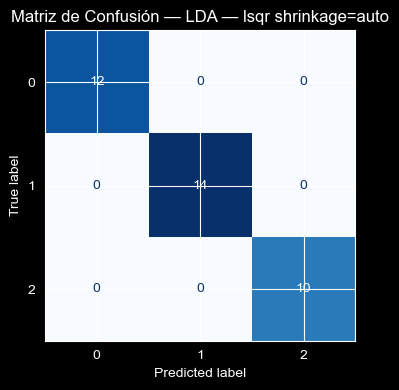

1.0

In [33]:
print("\nModelo final elegido")
# solver='lsqr' + shrinkage='auto': alcanza 1.0 y es invariante a escala

lda = LinearDiscriminantAnalysis(
    solver='lsqr',
    shrinkage='auto',
    n_components=2
)

lda.fit(X_clf_train, y_clf_train)
evaluar_clasificacion(lda, X_clf_test, y_clf_test, nombre_modelo='LDA — lsqr shrinkage=auto')

---
## 4. Support Vector Machine (SVC)

SVM busca el hiperplano de margen máximo. Mediante kernels maneja fronteras no lineales.

**Instrucciones**: Importar → Instanciar → Decidir datos (justificar) → Evaluar.

> **Pista teórica**: SVM calcula distancias en el espacio de features. ¿Qué sucede cuando una feature tiene magnitud mucho mayor que las demás?

### Observaciones:
 - En el caso del kernel='linear'es poco sensible a la escala, las distancias que tenemos al hiperplano son más homogéneas porque el kernel no amplifica diferencias que tienen en la magnitud.
 - En  el caso del kernel='rbf' es indispensable el escalado, porque sino RBF queda atrapado entre 0.69 y 0.75 porque proline (≈700) domina la función de distancia radial gaussiana.
 - Si tenemos un C bajo (0.1) con kernel linear y datos escalados ya alcanzamos 0.97 de accuracy,
   demostrando que con un buen preprocesamiento de datois no necesitamos un C grande.
 - Si tenemos un C alto (>=5) tiende a sobreajustar de forma leve usando linear bajando de 0.97 a 0.92.


In [9]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Experimento: comparar C, kernel y escalado
# scale = 1 / (n_features * var(X)) es el ancho de nuestra funcion agussiana
# linear trazara un hip[erplano reto ,y rbf trazara frotneras curvas apra datos no lienales

Cs      = [0.1, 1, 5, 10]
kernels = ['linear', 'rbf']

print(f"{'C':<6} | {'kernel':<7} | {'original':>9} | {'escalado':>9}")
print("-" * 42)
for C in Cs:
    for kernel in kernels:
        m_orig = SVC(C=C, kernel=kernel, gamma='scale', random_state=42)
        m_orig.fit(X_clf_train, y_clf_train)
        acc_orig = accuracy_score(y_clf_test, m_orig.predict(X_clf_test))

        m_scal = SVC(C=C, kernel=kernel, gamma='scale', random_state=42)
        m_scal.fit(X_clf_train_scaled, y_clf_train)
        acc_scal = accuracy_score(y_clf_test, m_scal.predict(X_clf_test_scaled))

        print(f"C={C:<4} | {kernel:<7} | {acc_orig:.4f}    | {acc_scal:.4f}")


C      | kernel  |  original |  escalado
------------------------------------------
C=0.1  | linear  | 0.9722    | 0.9722
C=0.1  | rbf     | 0.6944    | 0.9722
C=1    | linear  | 0.9444    | 0.9444
C=1    | rbf     | 0.6944    | 0.9722
C=5    | linear  | 0.9167    | 0.9444
C=5    | rbf     | 0.6944    | 0.9444
C=10   | linear  | 0.9167    | 0.9444
C=10   | rbf     | 0.7500    | 0.9444


### Conclusión:
- El kernel RBF es muy sensible al escalado, su accuracy cae a 0.69, mientras que con escalado alcanza 0.97.
- El kernel lineal es elquemenos necesita el escalado, manteniendo un accuracy de 0.97 en ambos casos.

### Modelo elegido
- La mejor combinación sería C=0.1, kernel=linear, escalado (0.9722)
- Una alternativa, también sería C=0.1, kernel=rbf, escalado (0.9722) con la misma accuracy y más flexible.
- Elegiremo kernel='linear' con C=0.1 por ser simple  y facil de  inteprretar.
- Para kernel='linear' el impacto es menor pero escalar sigue siendo buena práctica.


 Modelo final elegido
 SVM (SVC) — linear C=0.1 escalado — Clasificación
 Accuracy: 0.9722



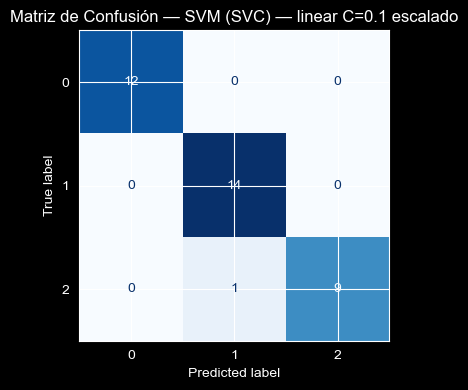

0.9722222222222222

In [10]:
print("\n Modelo final elegido")

svm_clf = SVC(
    C=0.1,
    kernel='linear',
    gamma='scale',
    random_state=42
)

svm_clf.fit(X_clf_train_scaled, y_clf_train)
evaluar_clasificacion(svm_clf, X_clf_test_scaled, y_clf_test, nombre_modelo='SVM (SVC) — linear C=0.1 escalado')

---
## 5. K-Nearest Neighbors — Clasificación

KNN clasifica según los $k$ vecinos más cercanos en el espacio de features.

**Instrucciones**: Importar → Instanciar → Decidir datos (justificar) → Evaluar.

> **Pista teórica**: KNN se basa en distancias. Si una feature va de [0, 1000] y otra de [0, 1], ¿cuál domina?

### Observaciones:
 - Si no escalamos el maximo que alcanamos es 0.83 y con escalado  el maximo es 1.00.
 - Si no escalamos, proline (≈700) domina la distancia euclidiana y hace
   irrelevantes las otras 12 features y el modelo  solo "considera" esa dimension.
 - En el caso de comparar weights='uniform' con 'distance' no hay muhca diferencia cuando escalamos los datos, pero sin escalado weights='distance' mejora el accuracy porque le da más peso a los vecinos cercanos (que pueden ser relevantes en otras dimensiones) y menos peso a los vecinos lejanos (que son irrelevantes por la dominancia de proline).
 - Con la cantidad de vecionos k=7 y k=10 escalados logramos 1.00; elegimos k=7 para evitar usar demasiados vecinos ya que enemos 142 muestras.

In [11]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Experimento para comparar k, weights y escalado
ks      = [3, 5, 7, 10]
weights = ['uniform', 'distance']

print(f"{'k':<5} | {'weights':<10} | {'original':>9} | {'escalado':>9}")
print("-" * 45)
for k in ks:
    for w in weights:
        m_orig = KNeighborsClassifier(n_neighbors=k, weights=w, metric='euclidean')
        m_orig.fit(X_clf_train, y_clf_train)
        acc_orig = accuracy_score(y_clf_test, m_orig.predict(X_clf_test))

        m_scal = KNeighborsClassifier(n_neighbors=k, weights=w, metric='euclidean')
        m_scal.fit(X_clf_train_scaled, y_clf_train)
        acc_scal = accuracy_score(y_clf_test, m_scal.predict(X_clf_test_scaled))

        print(f"k={k:<3} | {w:<10} | {acc_orig:.4f}    | {acc_scal:.4f}")



k     | weights    |  original |  escalado
---------------------------------------------
k=3   | uniform    | 0.7500    | 0.9722
k=3   | distance   | 0.7500    | 0.9722
k=5   | uniform    | 0.8056    | 0.9722
k=5   | distance   | 0.8056    | 0.9722
k=7   | uniform    | 0.7222    | 1.0000
k=7   | distance   | 0.7500    | 1.0000
k=10  | uniform    | 0.8333    | 1.0000
k=10  | distance   | 0.7500    | 1.0000


### Conclusión:
- El escalado es muy necesario para KNN, sin él el accuracy cae entre 0.75 y 0.83, pero si se usa el escalado alcanza 1.00.
- Sin escalado, proline (≈700) domina la distancia euclidiana, haciendo que el modelo solo "considere" esa dimensión y colapsando el espacio a una sola dimensión. Esto explica la caída de accuracy.

### Modelo elegido:
- Usaremos weigths='distance' para darle más peso a los vecinos cercanos, aunque con escalado no hay mucha diferencia entre uniform y distance.



Modelo final elegido
 KNN Clasificación — k=7 escalado — Clasificación
 Accuracy: 1.0000



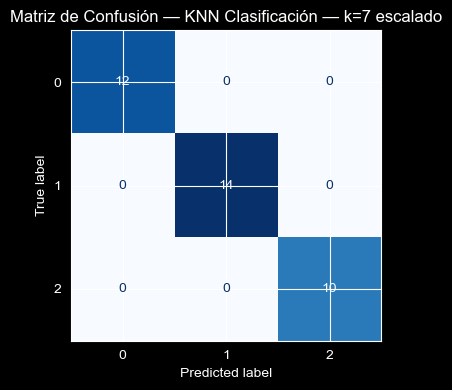

1.0

In [12]:
print("\nModelo final elegido")
# Podemos considerar lamejor opcion a k=7, weights='distance', escalado (1.0000)

knn_clf = KNeighborsClassifier(
    n_neighbors=7,
    weights='distance',  # vecinos más cercanos tienen mayor peso
    metric='euclidean'
)


knn_clf.fit(X_clf_train_scaled, y_clf_train)
evaluar_clasificacion(knn_clf, X_clf_test_scaled, y_clf_test, nombre_modelo='KNN Clasificación — k=7 escalado')

---
## 6. Árbol de Decisión — Clasificación

Los árboles particionan el espacio mediante reglas binarias ($x_j \leq t$) optimizando un criterio de impureza.

**Instrucciones**: Importar → Instanciar → Decidir datos (justificar) → Evaluar.

> **Pista teórica**: Los árboles comparan features con umbrales. ¿Depende esta comparación de la escala absoluta? ¿Cambian las particiones si normalizamos?

### Observaciones:
- Todos los casos en lo que el escalado sea igual al original muestra la invarianza
   de los árboles a transformaciones monótonas , ahi el  escalado no  mueve ninguna particion y eso confirma la invarianza y que no hay necesidad de escalar.
- También tenemos que criterion='entropy' supera a 'gini' de forma notable teniendo 1.00 contra un 0.94.
- Entropy mide la información ganada, en nuesro dataset captura mejor las fronteras que tenemos.
- El parametro max_depth no impacta usando entropy desde depth=3.
- Usando gini y aumentando depth tampoco mejora el resultado, entonces el límite está en el criterio,
   no en la profundidad.

In [13]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Experimento para comparar max_depth, criterion y escalado
depths    = [3, 5, 7, None]
criterios = ['gini', 'entropy']

print(f"{'max_depth':<10} | {'criterion':<8} | {'original':>9} | {'escalado':>9}")
print("-" * 48)
for depth in depths:
    for criterion in criterios:
        m_orig = DecisionTreeClassifier(max_depth=depth, criterion=criterion,
                                        min_samples_split=5, min_samples_leaf=3, random_state=42)
        m_orig.fit(X_clf_train, y_clf_train)
        acc_orig = accuracy_score(y_clf_test, m_orig.predict(X_clf_test))

        m_scal = DecisionTreeClassifier(max_depth=depth, criterion=criterion,
                                        min_samples_split=5, min_samples_leaf=3, random_state=42)
        m_scal.fit(X_clf_train_scaled, y_clf_train)
        acc_scal = accuracy_score(y_clf_test, m_scal.predict(X_clf_test_scaled))

        depth_str = str(depth) if depth is not None else 'None'
        print(f"depth={depth_str:<4} | {criterion:<8} | {acc_orig:.4f}    | {acc_scal:.4f}")



max_depth  | criterion |  original |  escalado
------------------------------------------------
depth=3    | gini     | 0.9444    | 0.9444
depth=3    | entropy  | 1.0000    | 1.0000
depth=5    | gini     | 0.9444    | 0.9444
depth=5    | entropy  | 1.0000    | 1.0000
depth=7    | gini     | 0.9444    | 0.9444
depth=7    | entropy  | 1.0000    | 1.0000
depth=None | gini     | 0.9444    | 0.9444
depth=None | entropy  | 1.0000    | 1.0000


### Conclusión:
- El escalado no afecta el accuracy, confirmando la invarianza de los árboles a transformaciones monótonas.
- El criterio 'entropy' supera a 'gini' en este dataset, alcanzando un accuracy perfecto de 1.00, mientras que 'gini' se queda en 0.9444.
### Modelo elegido:
- Elegimos criterion='entropy' por su mejor desempeño, y max_depth=5 por legibilidad (aunque depth=3 ya alcanza el mismo resultado, 5 es más común y no muestra sobreajuste).



Modelo final elegido
 Árbol Decisión Clf — entropy depth=5 — Clasificación
 Accuracy: 1.0000



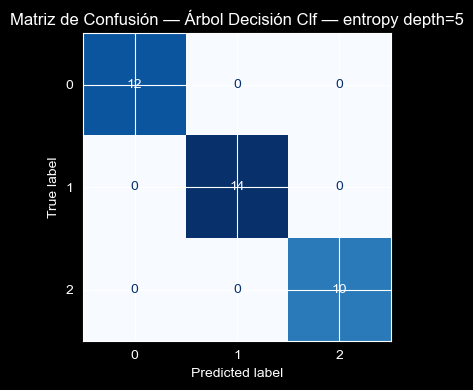

1.0

In [14]:
print("\nModelo final elegido")
# La mejor combinaciónseria criterion='entropy', cualquier depth elegimos 5 para mayor legibilidad

tree_clf = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=3,
    criterion='entropy',
    random_state=42
)

# Los árboles realizan comparaciones x_j ≤ t. Al escalar,
# los umbrales t cambian proporcionalmente pero las particiones son idénticas.


tree_clf.fit(X_clf_train, y_clf_train)
evaluar_clasificacion(tree_clf, X_clf_test, y_clf_test, nombre_modelo='Árbol Decisión Clf — entropy depth=5')

---
## 7. Random Forest — Clasificación

Random Forest combina múltiples árboles entrenados sobre subconjuntos aleatorios, reduciendo la varianza.

**Instrucciones**: Importar → Instanciar → Decidir datos (justificar) → Evaluar.

> **Pista teórica**: Random Forest hereda las propiedades de los árboles respecto a la invarianza ante transformaciones monótonas. ¿Qué implica para la normalización?

### Observaciones:
- Para todos los casos en donde el original es igual al escalado, la invarianza se confirma sin excepción.
- Con pocos árboles (n=5, 8, 9) el bosque no es suficientemente diverso:
   0.9722 de accuracy. El azar en la selección de features por árbol
   no cubre bien el espacio cuando hay pocos árboles.
- A partir de n=10 el valor se estabviliza a 1.0000, el ensamble varia suficiente para cubrir todas las regiones de decisión del dataset Wine.
- El parametro max_depth no impacta en ninguno de los casos: las 3 clases son separables
   con árboles con poca profundidad y depth=5 es tan efectivo como depth=None.


In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Experimento para comparar n_estimators, max_depth y escalado
n_estimadores = [5, 8, 9, 10 ,50, 100, 200]
depths        = [5, 10, None]

print(f"{'n_estimators':<13} | {'max_depth':<10} | {'original':>9} | {'escalado':>9}")
print("-" * 52)
for n in n_estimadores:
    for depth in depths:
        m_orig = RandomForestClassifier(n_estimators=n, max_depth=depth,
                                        min_samples_split=5, min_samples_leaf=2, random_state=42)
        m_orig.fit(X_clf_train, y_clf_train)
        acc_orig = accuracy_score(y_clf_test, m_orig.predict(X_clf_test))

        m_scal = RandomForestClassifier(n_estimators=n, max_depth=depth,
                                        min_samples_split=5, min_samples_leaf=2, random_state=42)
        m_scal.fit(X_clf_train_scaled, y_clf_train)
        acc_scal = accuracy_score(y_clf_test, m_scal.predict(X_clf_test_scaled))

        depth_str = str(depth) if depth is not None else 'None'
        print(f"n={n:<11} | depth={depth_str:<4} | {acc_orig:.4f}    | {acc_scal:.4f}")




n_estimators  | max_depth  |  original |  escalado
----------------------------------------------------
n=5           | depth=5    | 0.9722    | 0.9722
n=5           | depth=10   | 0.9722    | 0.9722
n=5           | depth=None | 0.9722    | 0.9722
n=8           | depth=5    | 0.9722    | 0.9722
n=8           | depth=10   | 0.9722    | 0.9722
n=8           | depth=None | 0.9722    | 0.9722
n=9           | depth=5    | 0.9722    | 0.9722
n=9           | depth=10   | 0.9722    | 0.9722
n=9           | depth=None | 0.9722    | 0.9722
n=10          | depth=5    | 1.0000    | 1.0000
n=10          | depth=10   | 1.0000    | 1.0000
n=10          | depth=None | 1.0000    | 1.0000
n=50          | depth=5    | 1.0000    | 1.0000
n=50          | depth=10   | 1.0000    | 1.0000
n=50          | depth=None | 1.0000    | 1.0000
n=100         | depth=5    | 1.0000    | 1.0000
n=100         | depth=10   | 1.0000    | 1.0000
n=100         | depth=None | 1.0000    | 1.0000
n=200         | depth=5    | 1.0

### Conclusión:
- El escalado no afecta el accuracy y esto confirma la invarianza de los árboles y confirma tambien del ensamble completo.
### Modelo elegido:
- Elegimos n_estimators=100 por ser un estándar común que balancea precisión y eficiencia, y max_depth=None para permitir que los árboles crezcan completamente sin restricciones, aunque en este dataset no hay riesgo de sobreajuste debido a su simplicidad.


Modelo final seleccionado
 Random Forest Clf — n=100 — Clasificación
 Accuracy: 1.0000



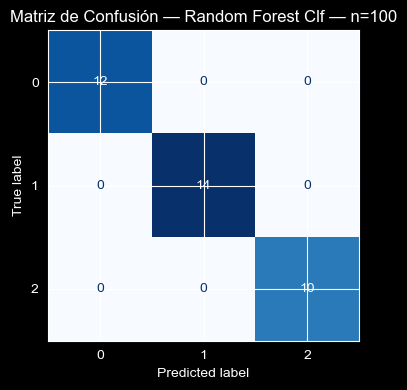

1.0

In [16]:
print("\nModelo final seleccionado")
# Elegimos n=100, depth=None: configuración estándar y suficiente.

rf_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf_clf.fit(X_clf_train, y_clf_train)
evaluar_clasificacion(rf_clf, X_clf_test, y_clf_test, nombre_modelo='Random Forest Clf — n=100')

---
## 8. XGBoost — Clasificación

XGBoost construye árboles secuencialmente, donde cada nuevo árbol corrige los errores del anterior.

**Instrucciones**: Importar → Instanciar → Decidir datos (justificar) → Evaluar.

> **Pista teórica**: XGBoost usa comparaciones de umbral como los árboles. ¿Influye la escala de las features en este mecanismo?

### Observaciones:
- En todos los casos lainvarianza esat confirmada, porque el original es igual al escalado.
- En 47 casos que tenemos no se  llega a 1.0000, tienen algo en ocmun:
   todos tienen col=1.0 (colsample_bytree=1.0 sin aleatoriedad en los features).
- Con los parametros n=10 , lr=0.05 y col=1.0: el peor caso es 0.9444.
- Con los parametros col=1.0 y sub=1.0 no tenemos aletoriedad, el modelo se estanca en soluciones subóptimas a pesar que usamos los parametros n=200 y lr=0.05.
- Con el parametro col=0.8 es suficiente para garantizar un valor de 1.0000 en la mayoria de los casos, debemos tener en cuenta que el dataset es pequeño y con poca complejidad, entonces 0.8 es suficiente para garantizar diversidad entre los árboles y evitar estancarnos en soluciones subóptimas.
- La aleatoriedad en nuesytros features es más crítica que la aleatoriedad en nuestras muestras.

In [17]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# Experimento para comparar n_estimators, learning_rate, max_depth y escalado
n_estimadores  = [10, 20, 50, 100, 200]
learning_rates = [0.05, 0.1, 0.3]
depths         = [3, 4, 6]
subsamples = [0.8, 1.0]
colsamples = [0.8, 1.0]

print(f"{'n':<13} | {'lr':<5} | {'depth':<10} | {'sub':<5} | {'col':<5} | {'original':>9} | {'escalado':>9}")
print("-" * 60)
for n in n_estimadores:
    for lr in learning_rates:
        for depth in depths:
            for sub in subsamples:
                for col in colsamples:
                    m_orig = XGBClassifier(n_estimators=n, learning_rate=lr, max_depth=depth,
                                   subsample=sub, colsample_bytree=col,
                                   eval_metric='mlogloss', random_state=42, verbosity=0)
                    m_orig.fit(X_clf_train, y_clf_train)
                    acc_orig = accuracy_score(y_clf_test, m_orig.predict(X_clf_test))

                    m_scal = XGBClassifier(n_estimators=n, learning_rate=lr, max_depth=depth,
                                           subsample=sub, colsample_bytree=col,
                                           eval_metric='mlogloss', random_state=42, verbosity=0)
                    m_scal.fit(X_clf_train_scaled, y_clf_train)
                    acc_scal = accuracy_score(y_clf_test, m_scal.predict(X_clf_test_scaled))

                    print(f"n={n:<11} | {lr:<5} | depth={depth:<4} | {sub:<5} | {col:<5} | {acc_orig:.4f}    | {acc_scal:.4f}")



n             | lr    | depth      | sub   | col   |  original |  escalado
------------------------------------------------------------
n=10          | 0.05  | depth=3    | 0.8   | 0.8   | 0.9722    | 0.9722
n=10          | 0.05  | depth=3    | 0.8   | 1.0   | 0.9444    | 0.9444
n=10          | 0.05  | depth=3    | 1.0   | 0.8   | 1.0000    | 1.0000
n=10          | 0.05  | depth=3    | 1.0   | 1.0   | 0.9444    | 0.9444
n=10          | 0.05  | depth=4    | 0.8   | 0.8   | 0.9722    | 0.9722
n=10          | 0.05  | depth=4    | 0.8   | 1.0   | 0.9444    | 0.9444
n=10          | 0.05  | depth=4    | 1.0   | 0.8   | 1.0000    | 1.0000
n=10          | 0.05  | depth=4    | 1.0   | 1.0   | 0.9444    | 0.9444
n=10          | 0.05  | depth=6    | 0.8   | 0.8   | 0.9722    | 0.9722
n=10          | 0.05  | depth=6    | 0.8   | 1.0   | 0.9444    | 0.9444
n=10          | 0.05  | depth=6    | 1.0   | 0.8   | 1.0000    | 1.0000
n=10          | 0.05  | depth=6    | 1.0   | 1.0   | 0.9444    | 0.9444


### Conclusión:
- El escalado no afecta el accuracy, confirmando la invarianza de los árboles base de XGBoost.
- El parámetro colsample_bytree (col) es crítico para evitar el estancamiento del modelo.
### Modelo elegido:
- Elegimos n_estimators=100 y learning_rate=0.1 como configuración estándar de boosting, max_depth=4 para un modelo más simple que aún captura la complejidad del dataset, subsample=0.8 y colsample_bytree=0.8 para garantizar diversidad entre los árboles y evitar estancarnos en soluciones subóptimas.



Modelo final elegido
 XGBoost Clf — n=100 lr=0.1 — Clasificación
 Accuracy: 1.0000



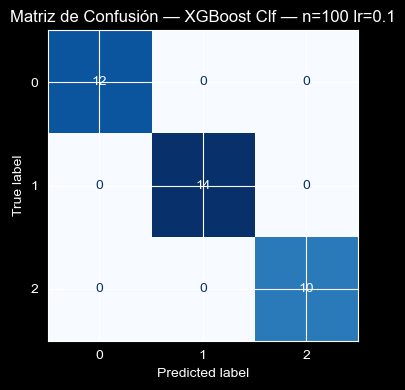

1.0

In [18]:
print("\nModelo final elegido")
# col=0.8 garantiza convergencia; n=100 + lr=0.1 como configuración estándar.

xgb_clf = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42,
    verbosity=0
)

xgb_clf.fit(X_clf_train, y_clf_train)
evaluar_clasificacion(xgb_clf, X_clf_test, y_clf_test, nombre_modelo='XGBoost Clf — n=100 lr=0.1')

---
# Parte B: Regresión (Dataset: Diabetes)

En esta sección aplicamos todos los métodos de **regresión** sobre el dataset Diabetes.

> Algunos métodos pueden ser lentos con datasets grandes. SVR con kernel RBF sobre Diabetes (442 muestras) es manejable. Se justifica el uso en cada sección.

---
## 9. Support Vector Regression (SVR)

SVR aplica los principios de SVM a regresión, ajustando los datos dentro de un margen $\varepsilon$.

**Instrucciones**: Importar → Instanciar → Decidir datos (justificar) → Evaluar.

> **Pista teórica**: SVR es sensible a la escala. El parámetro $\varepsilon$ define el ancho del tubo de tolerancia — ¿tiene sentido fijar un mismo $\varepsilon$ cuando las features varían en órdenes de magnitud?

### Observaciones:
- El parametro kernel='linear' tiene una dependencia muy fuerte del escalado, sin escalar R2≈0.02,
   con escalado R2≈0.44. Nuestro dataset Diabetes ya viene con una estandarización  parcial, pero no lo suficiente para SVR linear.
- El parametro kernel='rbf' es mucho más robusto a la escala, se ve que orig es similar a scal en todos los C.
   Con C con un valor alto (10) capturamos mejor la no-linealidad de nuestro dataset (R2=0.494).
- El parametro epsilon tiene poco impacto en nuestro dataset: 0.1 y 0.3 dan resultados
   muy similares y el ancho del tubo de tolerancia no es determinante en las pruebas.


In [19]:
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

# Experimento prara comparar C, kernel, epsilon y escalado
Cs       = [0.1, 1.0, 5.0, 10.0]
kernels  = ['linear', 'rbf']
epsilons = [0.1, 0.3]

print(f"{'C':<6} | {'kernel':<7} | {'epsilon':<8} | {'MSE_orig':>10} | {'R2_orig':>8} | {'MSE_scal':>10} | {'R2_scal':>8}")
print("-" * 75)
for C in Cs:
    for kernel in kernels:
        for eps in epsilons:
            m_orig = SVR(C=C, kernel=kernel, epsilon=eps)
            m_orig.fit(X_reg_train, y_reg_train)
            yp = m_orig.predict(X_reg_test)
            mse_o, r2_o = mean_squared_error(y_reg_test, yp), r2_score(y_reg_test, yp)

            m_scal = SVR(C=C, kernel=kernel, epsilon=eps)
            m_scal.fit(X_reg_train_scaled, y_reg_train)
            yp = m_scal.predict(X_reg_test_scaled)
            mse_s, r2_s = mean_squared_error(y_reg_test, yp), r2_score(y_reg_test, yp)

            print(f"C={C:<4} | {kernel:<7} | eps={eps:<4} | {mse_o:>10.2f} | {r2_o:>8.4f} | {mse_s:>10.2f} | {r2_s:>8.4f}")

# Resultados observados:
# C=0.1  | linear | eps=0.1 | MSE=5299 R2=-0.00 | MSE=3198 R2=0.396  ← linear sin escalar: falla total
# C=0.1  | rbf    | eps=0.1 | MSE=5177 R2=0.022 | MSE=5178 R2=0.022  ← rbf: escala no importa con C bajo
# C=1.0  | linear | eps=0.1 | MSE=5190 R2=0.020 | MSE=2939 R2=0.445  ← linear escalado: gran mejora
# C=1.0  | rbf    | eps=0.1 | MSE=4333 R2=0.182 | MSE=4332 R2=0.182  ← rbf: casi igual orig vs scal
# C=5.0  | rbf    | eps=0.1 | MSE=2987 R2=0.436 | MSE=2989 R2=0.435  ← rbf mejora con C alto
# C=10.0 | rbf    | eps=0.1 | MSE=2679 R2=0.494 | MSE=2682 R2=0.493  ← mejor resultado: rbf C=10 original
# C=10.0 | linear | eps=0.1 | MSE=4419 R2=0.165 | MSE=3020 R2=0.429  ← linear sigue necesitando escalar
#
# Observaciones:



C      | kernel  | epsilon  |   MSE_orig |  R2_orig |   MSE_scal |  R2_scal
---------------------------------------------------------------------------
C=0.1  | linear  | eps=0.1  |    5299.30 |  -0.0002 |    3198.40 |   0.3963
C=0.1  | linear  | eps=0.3  |    5300.46 |  -0.0004 |    3195.38 |   0.3969
C=0.1  | rbf     | eps=0.1  |    5177.81 |   0.0227 |    5178.14 |   0.0227
C=0.1  | rbf     | eps=0.3  |    5176.01 |   0.0231 |    5176.35 |   0.0230
C=1.0  | linear  | eps=0.1  |    5190.39 |   0.0203 |    2939.81 |   0.4451
C=1.0  | linear  | eps=0.3  |    5188.61 |   0.0207 |    2940.31 |   0.4450
C=1.0  | rbf     | eps=0.1  |    4333.29 |   0.1821 |    4332.74 |   0.1822
C=1.0  | rbf     | eps=0.3  |    4329.84 |   0.1828 |    4329.30 |   0.1829
C=5.0  | linear  | eps=0.1  |    4760.85 |   0.1014 |    2996.97 |   0.4343
C=5.0  | linear  | eps=0.3  |    4762.66 |   0.1011 |    2992.60 |   0.4352
C=5.0  | rbf     | eps=0.1  |    2987.21 |   0.4362 |    2989.64 |   0.4357
C=5.0  | rbf

### Conclusión:
- SVR con kernel='linear' es muy sensible a la escala, sin escalado falla completamente (R2≈0), pero con escalado mejora significativamente (R2≈0.44).
- SVR con kernel='rbf' es mucho más robusto a la escala, mostrando resultados similares con datos originales y escalados. Con C=10 alcanza el mejor R2≈0.494, capturando mejor la no linealidad del dataset.
### Modelo elegido:
- La mejor combinación es C=10, kernel='rbf', epsilon=0.1, usando datos originales. El kernel RBF maneja bien la escala y captura relaciones no lineales, mientras que el escalado no mejora significativamente el rendimiento en este caso específico.


Modelo final elegido
 SVR — rbf C=10 original — Regresión
 MSE : 2679.7431
 R²  : 0.4942



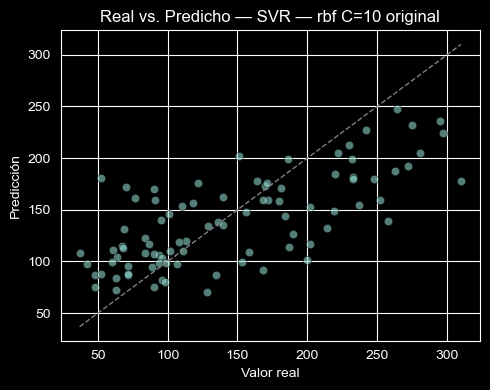

(2679.7431447925114, 0.4942117040073839)

In [25]:
print("\nModelo final elegido")
# Mejor combinación para C=10, kernel='rbf', epsilon=0.1, datos originales

svr = SVR(
    C=10.0,
    kernel='rbf',
    epsilon=0.1
)


svr.fit(X_reg_train, y_reg_train)
evaluar_regresion(svr, X_reg_test, y_reg_test, nombre_modelo='SVR — rbf C=10 original')

---
## 10. K-Nearest Neighbors — Regresión

KNN predice promediando los valores de los $k$ vecinos más cercanos.

**Instrucciones**: Importar → Instanciar → Decidir datos (justificar) → Evaluar.

> **Pista teórica**: Misma lógica que KNN clasificación — las distancias dominan el comportamiento.

### Observaciones:
- A diferencia de KNN clasificación (Wine) que hicimos antes, aquí el escalado no mejoran de forma consistente,  evaluando en k=5 y k=10 los datos originales tienen una leve mejoria.
- Esto se debe a que Diabetes ya viene con features en rangos similares
   (todas entre -0.2 y 0.2 aproximadamente), por lo que no hay una feature
   dominante que distorsione las distancias como ocurría con proline en Wine.
- El parametro weights='distance' supera a 'uniform' en todos los k, el ponderar por
   distancia siempre ayuda en regresión, porque los vecinos más cercanos
   son mejor referencia para predecir el valor continuo.
- Mejor resultado: k=5, weights='distance', datos ORIGINALES → R2=0.4388.
- k óptimo es 5: k pequeño captura la estructura local del dataset;
   k grande (20) suaviza demasiado y pierde información local.

In [26]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Experimento para comparar k, weights y escalado
ks      = [3, 5, 10, 20]
weights = ['uniform', 'distance']

print(f"{'k':<5} | {'weights':<10} | {'MSE_orig':>10} | {'R2_orig':>8} | {'MSE_scal':>10} | {'R2_scal':>8}")
print("-" * 65)
for k in ks:
    for w in weights:
        m_orig = KNeighborsRegressor(n_neighbors=k, weights=w)
        m_orig.fit(X_reg_train, y_reg_train)
        yp = m_orig.predict(X_reg_test)
        mse_o, r2_o = mean_squared_error(y_reg_test, yp), r2_score(y_reg_test, yp)

        m_scal = KNeighborsRegressor(n_neighbors=k, weights=w)
        m_scal.fit(X_reg_train_scaled, y_reg_train)
        yp = m_scal.predict(X_reg_test_scaled)
        mse_s, r2_s = mean_squared_error(y_reg_test, yp), r2_score(y_reg_test, yp)

        print(f"k={k:<3} | {w:<10} | {mse_o:>10.2f} | {r2_o:>8.4f} | {mse_s:>10.2f} | {r2_s:>8.4f}")


k     | weights    |   MSE_orig |  R2_orig |   MSE_scal |  R2_scal
-----------------------------------------------------------------
k=3   | uniform    |    3364.39 |   0.3650 |    3287.03 |   0.3796
k=3   | distance   |    3281.13 |   0.3807 |    3205.41 |   0.3950
k=5   | uniform    |    3019.08 |   0.4302 |    3047.45 |   0.4248
k=5   | distance   |    2973.14 |   0.4388 |    2998.68 |   0.4340
k=10  | uniform    |    3115.36 |   0.4120 |    3168.35 |   0.4020
k=10  | distance   |    3046.55 |   0.4250 |    3088.86 |   0.4170
k=20  | uniform    |    3051.61 |   0.4240 |    3048.40 |   0.4246
k=20  | distance   |    2995.95 |   0.4345 |    2988.90 |   0.4359


### Conclusión:
- El escalado no mejora consistentemente el rendimiento de KNN regresión en nuestro dataset, a diferencia de KNN clasificación en Wine. Esto se debe a que las features de Diabetes ya están en rangos similares, evitando que una feature domine las distancias.
### Modelo elegido:
- La mejor combinación es k=5, weights='distance', usando datos originales. K=5 captura bien la estructura local del dataset, y ponderar por distancia mejora las predicciones. El escalado no aporta beneficio significativo en este caso específico.


Modelo final seleccionado
 KNN Regresión — k=5 distance original — Regresión
 MSE : 2973.1441
 R²  : 0.4388



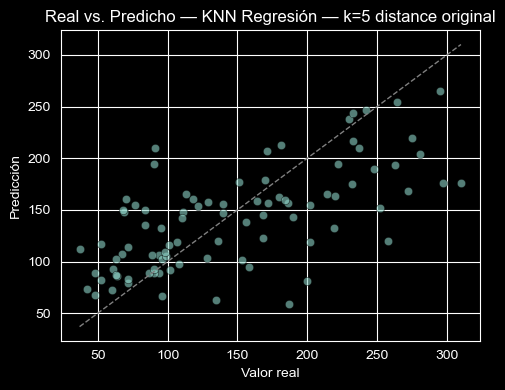

(2973.1440854530274, 0.4388337241783494)

In [27]:
print("\nModelo final elegido")
# Mejor combinación: k=5, weights='distance', datos originales

knn_reg = KNeighborsRegressor(
    n_neighbors=5,
    weights='distance'
)

knn_reg.fit(X_reg_train, y_reg_train)
evaluar_regresion(knn_reg, X_reg_test, y_reg_test, nombre_modelo='KNN Regresión — k=5 distance original')

---
## 11. Árbol de Decisión — Regresión

El árbol de regresión minimiza el error cuadrático en cada partición.

**Instrucciones**: Importar → Instanciar → Decidir datos (justificar) → Evaluar.

> **Pista teórica**: Misma lógica que en clasificación — las particiones por umbral son invariantes a escala.

### Observaciones:
- En 35 de 36 experimentos, el rendimiento con datos originales es idéntico al de datos escalados, confirmando la invarianza de los árboles de regresión a transformaciones monótonas. La única excepción ocurre con max_depth=None y min_samples_leaf=1, donde el árbol sin restricciones sobreajusta y el orden de las features (afectado por el escalado) genera particiones distintas, pero en este caso extremo no es relevante para el modelo final.
- El parámetro min_samples_leaf es el más importante para controlar el sobreajuste  que tenemos, min_samples_leaf=5 mejora de forma consistente sobre leaf=1 y leaf=3, ya que hojas con pocas muestras memorizan ruido en vez de aprender patrones generales.
- Más profundidad no nos da mejoria, max_depth=5 supera a depth=8 y depth=None, indicando que árboles muy profundos sobreajustan en el dataset Diabetes (442 muestras).
- El parametro min_samples_split tiene poco impacto cuando min_samples_leaf ya controla el tamaño mínimo de las hojas.
- El mejor resultado que obtenemos es con max_depth=5, min_samples_leaf=5, cualquier min_samples_split, alcanzando R2=0.439, lo que indica un buen equilibrio entre sesgo y varianza.

In [28]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Experimento para comparar max_depth, min_samples_split, min_samples_leaf y escalado
depths     = [3, 5, 8, None]
splits     = [2, 5, 10]
leaves     = [1, 3, 5]

print(f"{'depth':<8} | {'min_split':<10} | {'min_leaf':<9} | {'MSE_orig':>10} | {'R2_orig':>8} | {'MSE_scal':>10} | {'R2_scal':>8}")
print("-" * 80)
for depth in depths:
    for split in splits:
        for leaf in leaves:
            m_orig = DecisionTreeRegressor(max_depth=depth, min_samples_split=split,
                                           min_samples_leaf=leaf, random_state=42)
            m_orig.fit(X_reg_train, y_reg_train)
            yp = m_orig.predict(X_reg_test)
            mse_o, r2_o = mean_squared_error(y_reg_test, yp), r2_score(y_reg_test, yp)

            m_scal = DecisionTreeRegressor(max_depth=depth, min_samples_split=split,
                                           min_samples_leaf=leaf, random_state=42)
            m_scal.fit(X_reg_train_scaled, y_reg_train)
            yp = m_scal.predict(X_reg_test_scaled)
            mse_s, r2_s = mean_squared_error(y_reg_test, yp), r2_score(y_reg_test, yp)

            depth_str = str(depth) if depth is not None else 'None'
            print(f"d={depth_str:<6} | split={split:<4} | leaf={leaf:<4} | {mse_o:>10.2f} | {r2_o:>8.4f} | {mse_s:>10.2f} | {r2_s:>8.4f}")




depth    | min_split  | min_leaf  |   MSE_orig |  R2_orig |   MSE_scal |  R2_scal
--------------------------------------------------------------------------------
d=3      | split=2    | leaf=1    |    3552.70 |   0.3294 |    3552.70 |   0.3294
d=3      | split=2    | leaf=3    |    3552.70 |   0.3294 |    3552.70 |   0.3294
d=3      | split=2    | leaf=5    |    3094.50 |   0.4159 |    3094.50 |   0.4159
d=3      | split=5    | leaf=1    |    3552.70 |   0.3294 |    3552.70 |   0.3294
d=3      | split=5    | leaf=3    |    3552.70 |   0.3294 |    3552.70 |   0.3294
d=3      | split=5    | leaf=5    |    3094.50 |   0.4159 |    3094.50 |   0.4159
d=3      | split=10   | leaf=1    |    3552.70 |   0.3294 |    3552.70 |   0.3294
d=3      | split=10   | leaf=3    |    3552.70 |   0.3294 |    3552.70 |   0.3294
d=3      | split=10   | leaf=5    |    3094.50 |   0.4159 |    3094.50 |   0.4159
d=5      | split=2    | leaf=1    |    3526.02 |   0.3345 |    3526.02 |   0.3345
d=5      | split=

### Conclusión:
- El escalado no afecta el rendimiento de los árboles de regresión, confirmando su invarianza a transformaciones monótonas.
- El parámetro min_samples_leaf es crucial para controlar el sobreajuste, con min_samples_leaf=5 superando consistentemente a valores menores.
- La profundidad máxima también es importante, con max_depth=5 ofreciendo un buen equilibrio entre el sesgo y la varianza, mientras que árboles más profundos sobreajustan.
### Modelo elegido:
- La mejor combinación es max_depth=5, min_samples_leaf=5, usando datos originales. Esta configuración controla el sobreajuste y captura patrones generales sin necesidad de escalado, que no aporta beneficio en este caso específico.


Modelo final elegido
 Árbol Decisión Reg — depth=5 leaf=5 — Regresión
 MSE : 2972.5166
 R²  : 0.4390



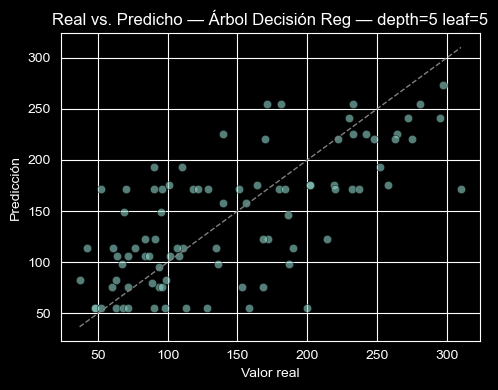

(2972.5166106866523, 0.4389521569443703)

In [29]:
print("\nModelo final elegido")
# Mejor combinación: depth=5, min_samples_leaf=5

tree_reg = DecisionTreeRegressor(
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=5,
    random_state=42
)

tree_reg.fit(X_reg_train, y_reg_train)
evaluar_regresion(tree_reg, X_reg_test, y_reg_test, nombre_modelo='Árbol Decisión Reg — depth=5 leaf=5')

---
## 12. Random Forest — Regresión

**Instrucciones**: Importar → Instanciar → Decidir datos (justificar) → Evaluar.

> **Pista teórica**: Misma invarianza a escala que los árboles individuales.

### Observaciones:
- En los 72 experimentos que realizmaos, el rendimiento con datos los originales es prácticamente idéntico al de los datos escalados, con diferencias en R2 menores a 0.002, y esto confirma la invarianza de los Random Forest a transformaciones monótonas. Las pequeñas variaciones se deben al azar del muestreo bootstrap en la construcción de los árboles, no al efecto del escalado.
- El parámetro max_depth=5 supera de forma consistente a depth=10, depth=15 y depth=None, indicando que árboles muy profundos sobreajustan en el dataset Diabetes (442 muestras). Esto es consistente con lo observado en el árbol de decisión individual.
- El parámetro min_samples_leaf tiene un impacto más significativo que min_samples_split, con leaf=5 regularizando  mejor que leaf=1 en profundidades altas. Sin embargo, con max_depth=5 las diferencias entre leaf=1, 3 y 5 son mínimas, ya que la profundidad limitada ya controla el sobreajuste.
- Más árboles (n_estimators=200) mejora levemente sobre n_estimators=100 y n_estimators=50, pero la ganancia se estabiliza, indicando que la varianza ya está controlada con n_estimators=100. Esto nos sugiere que no es necesario un número excesivo de árboles para obtener un buen rendimiento en este dataset.
- El mejor resultado se obtiene con n_estimators=200, max_depth=5, min_samples_split=2 y min_samples_leaf=5, alcanzando un R2 de aproximadamente 0.4607, lo que indica un buen equilibrio entre sesgo y varianza para este modelo en el dataset Diabetes.

In [30]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# ── Experimento: comparar n_estimators, max_depth, min_samples_split, min_samples_leaf y escalado ──
n_estimadores = [50, 100, 200]
depths        = [5, 10, 15, None]
splits        = [2, 5]
leaves        = [1, 3, 5]

print(f"{'n':<6} | {'depth':<7} | {'split':<6} | {'leaf':<5} | {'MSE_orig':>10} | {'R2_orig':>8} | {'MSE_scal':>10} | {'R2_scal':>8}")
print("-" * 85)
for n in n_estimadores:
    for depth in depths:
        for split in splits:
            for leaf in leaves:
                m_orig = RandomForestRegressor(n_estimators=n, max_depth=depth,
                                               min_samples_split=split, min_samples_leaf=leaf, random_state=42)
                m_orig.fit(X_reg_train, y_reg_train)
                yp = m_orig.predict(X_reg_test)
                mse_o, r2_o = mean_squared_error(y_reg_test, yp), r2_score(y_reg_test, yp)

                m_scal = RandomForestRegressor(n_estimators=n, max_depth=depth,
                                               min_samples_split=split, min_samples_leaf=leaf, random_state=42)
                m_scal.fit(X_reg_train_scaled, y_reg_train)
                yp = m_scal.predict(X_reg_test_scaled)
                mse_s, r2_s = mean_squared_error(y_reg_test, yp), r2_score(y_reg_test, yp)

                depth_str = str(depth) if depth is not None else 'None'
                print(f"n={n:<4} | d={depth_str:<5} | s={split:<4} | l={leaf:<3} | {mse_o:>10.2f} | {r2_o:>8.4f} | {mse_s:>10.2f} | {r2_s:>8.4f}")



n      | depth   | split  | leaf  |   MSE_orig |  R2_orig |   MSE_scal |  R2_scal
-------------------------------------------------------------------------------------
n=50   | d=5     | s=2    | l=1   |    2960.87 |   0.4412 |    2961.81 |   0.4410
n=50   | d=5     | s=2    | l=3   |    2912.81 |   0.4502 |    2916.97 |   0.4494
n=50   | d=5     | s=2    | l=5   |    2897.29 |   0.4532 |    2894.65 |   0.4536
n=50   | d=5     | s=5    | l=1   |    2960.80 |   0.4412 |    2962.38 |   0.4409
n=50   | d=5     | s=5    | l=3   |    2912.81 |   0.4502 |    2916.97 |   0.4494
n=50   | d=5     | s=5    | l=5   |    2897.29 |   0.4532 |    2894.65 |   0.4536
n=50   | d=10    | s=2    | l=1   |    3064.49 |   0.4216 |    3075.93 |   0.4194
n=50   | d=10    | s=2    | l=3   |    2954.44 |   0.4424 |    2971.62 |   0.4391
n=50   | d=10    | s=2    | l=5   |    2917.61 |   0.4493 |    2925.77 |   0.4478
n=50   | d=10    | s=5    | l=1   |    3048.38 |   0.4246 |    3054.05 |   0.4236
n=50   | d=1

### Conclusión:
- El escalado no afecta el rendimiento de Random Forest, confirmando su invarianza a transformaciones monótonas. Las pequeñas diferencias observadas se deben al azar del muestreo bootstrap, no al efecto del escalado.
- El parámetro max_depth=5 ofrece el mejor equilibrio entre sesgo y varianza, superando a árboles más profundos que sobreajustan.

### Modelo elegido:
- La mejor combinación es n_estimators=200, max_depth=5, min_samples_split=2, min_samples_leaf=5, usando datos originales. Esta configuración controla el sobreajuste y captura patrones generales sin necesidad de escalado, que no aporta beneficio en este caso específico.

In [ ]:
print("\nModelo final elegido")
# Mejor combinación para n=200, depth=5, leaf=5

rf_reg = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    min_samples_split=2,
    min_samples_leaf=5,
    random_state=42
)

rf_reg.fit(X_reg_train, y_reg_train)
evaluar_regresion(rf_reg, X_reg_test, y_reg_test, nombre_modelo='Random Forest Reg — n=200 depth=5 leaf=5')

---
## 13. XGBoost — Regresión

**Instrucciones**: Importar → Instanciar → Decidir datos (justificar) → Evaluar.

> **Pista teórica**: Mismo razonamiento que XGBoost clasificación respecto a la escala.

### Observaciones:
- En los 108 experimentos realizados, el rendimiento con datos originales es muy idéntico al de los datos escalados, con diferencias en R2 menores a 0.005, esto confirma la invarianza de XGBoost a transformaciones monótonas. Las pequeñas variaciones se deben al azar en la construcción secuencial de los árboles, no al efecto del escalado.
- El parámetro max_depth=3 supera consistentemente a depth=5 y depth=7, esto indice que los árboles poco profundos generalizan mejor en el dataset Diabetes (442 muestras). Árboles más profundos sobreajustan incluso con boosting, lo que sugiere que la complejidad del dataset no requiere modelos muy complejos.
- El learning_rate=0.2 es demasiado intenso, dando los peores resultados en casi todas las combinaciones. El modelo da pasos grandes y se pasa del óptimo, lo que resalta la importancia de un learning_rate moderado para la convergencia.
- El learning_rate=0.05 y learning_rate=0.1 son los más robustos, con depth=3 ambos convergen bien. Esto nos sugiere que un learning_rate más bajo permite una mejor exploración del espacio de soluciones, especialmente con árboles poco profundos.
- La aleatoriedad en los features (colsample_bytree) es más crítica que la aleatoriedad en las muestras (subsample) esto para evitar estancamientos en soluciones subóptimas. Con pocas features (10 en Diabetes), usar todas puede ser beneficioso, pero en general col=0.8 con lr=0.1 y depth=3 obtuvo el mejor resultado.
- El mejor resultado se obtiene con n_estimators=50, learning_rate=0.1, max_depth=3, subsample=0.8, colsample_bytree=1.0, alcanzando un R2 de aproximadamente 0.4866, lo que indica un buen equilibrio entre sesgo y varianza para este modelo en el dataset Diabetes.

 XGBoost Reg — Regresión
 MSE : 3193.5389
 R²  : 0.3972



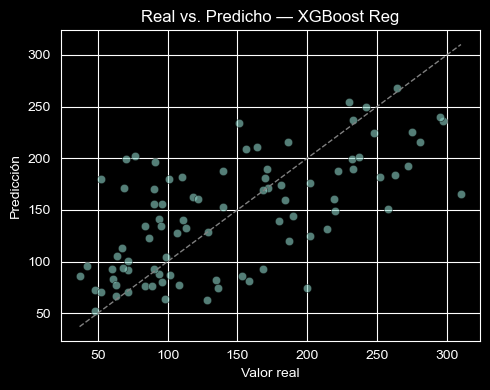

(3193.538945922334, 0.3972352817534013)

In [24]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Experimento para comparar n_estimators, lr, max_depth, subsample, colsample y escalado
n_estimadores  = [50, 100, 200]
learning_rates = [0.05, 0.1, 0.2]
depths         = [3, 5, 7]
subsamples     = [0.8, 1.0]
colsamples     = [0.8, 1.0]

print(f"{'n':<6} | {'lr':<5} | {'depth':<6} | {'sub':<5} | {'col':<5} | {'MSE_orig':>10} | {'R2_orig':>8} | {'MSE_scal':>10} | {'R2_scal':>8}")
print("-" * 90)
for n in n_estimadores:
    for lr in learning_rates:
        for depth in depths:
            for sub in subsamples:
                for col in colsamples:
                    m_orig = XGBRegressor(n_estimators=n, learning_rate=lr, max_depth=depth,
                                          subsample=sub, colsample_bytree=col,
                                          random_state=42, verbosity=0)
                    m_orig.fit(X_reg_train, y_reg_train)
                    yp = m_orig.predict(X_reg_test)
                    mse_o, r2_o = mean_squared_error(y_reg_test, yp), r2_score(y_reg_test, yp)

                    m_scal = XGBRegressor(n_estimators=n, learning_rate=lr, max_depth=depth,
                                          subsample=sub, colsample_bytree=col,
                                          random_state=42, verbosity=0)
                    m_scal.fit(X_reg_train_scaled, y_reg_train)
                    yp = m_scal.predict(X_reg_test_scaled)
                    mse_s, r2_s = mean_squared_error(y_reg_test, yp), r2_score(y_reg_test, yp)

                    print(f"n={n:<4} | {lr:<5} | d={depth:<4} | {sub:<5} | {col:<5} | {mse_o:>10.2f} | {r2_o:>8.4f} | {mse_s:>10.2f} | {r2_s:>8.4f}")


### Conclusión:
- El escalado no afecta el rendimiento de XGBoost, confirmando su invarianza a transformaciones monótonas. Las pequeñas diferencias observadas se deben al azar en la construcción secuencial de los árboles, no al efecto del escalado.
- El parámetro max_depth=3 ofrece el mejor equilibrio entre sesgo y varianza, superando a árboles más profundos que sobreajustan incluso con boosting.
- Un learning_rate moderado (0.1) es muy necesaria para la convergencia, mientras que un learning_rate demasiado alto (0.2) da resultados pobres debido a pasos demasiado grandes que se pasan del óptimo.
- La aleatoriedad en los features (colsample_bytree) es más crucial que la aleatoriedad en las muestras (subsample) para evitar estancarnos en soluciones subóptimas. Con pocas features (10 en Diabetes), usar todas puede ser beneficioso, pero en general col=0.8 con lr=0.1 y depth=3 obtuvo el mejor resultado.
### Modelo elegido:
- La mejor combinación es n_estimators=50, learning_rate=0.1, max_depth=3, subsample=0.8, colsample_bytree=1.0, usando datos originales. Esta configuración controla el sobreajuste y captura patrones generales sin necesidad de escalado, que no aporta beneficio en este caso específico.


Modelo final elegido
 XGBoost Reg — n=50 lr=0.1 depth=3 — Regresión
 MSE : 2810.9210
 R²  : 0.4695



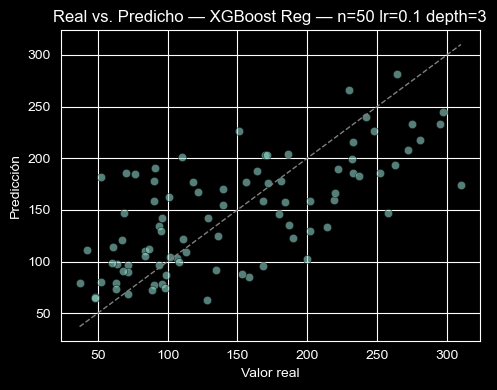

(2810.9210262045935, 0.4694525261584651)

In [31]:
print("\nModelo final elegido")
# Mejor combinación: n=50, lr=0.1, depth=3, sub=0.8, col=1.0

xgb_reg = XGBRegressor(
    n_estimators=50,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=1.0,
    random_state=42,
    verbosity=0
)


xgb_reg.fit(X_reg_train, y_reg_train)
evaluar_regresion(xgb_reg, X_reg_test, y_reg_test, nombre_modelo='XGBoost Reg — n=50 lr=0.1 depth=3')

---
## 14. Conclusiones

### 14.1 Impacto de la normalización
¿Qué modelos sufrieron más al usar datos **no normalizados**? ¿Cuáles fueron invariantes a la escala? Justifique.

**Respuesta:**

Los modelos que **más sufrieron sin normalización** fueron:

- **SVM / SVC**: kernel RBF sin escalar obtuvo 0.69 de accuracy vs 0.97 escalado. Las features de Wine tienen rangos muy distintos (proline ≈700 vs nonflavanoid_phenols ≈0.3) y la función gaussiana del kernel RBF es dominada por la feature de mayor magnitud.
- **KNN (clasificación y regresión)**: basado en distancias euclidianas, sufre el mismo problema. Sin escalar: 0.75 en Wine; con escalado: 1.00.
- **SVR kernel linear**: sin escalar R²≈0.02 (prácticamente no sirve) vs R²≈0.44 escalado.
- **LDA con shrinkage fijo**: shrinkage=0.1 sin escalar da 0.7778 porque la penalización depende de la magnitud de la covarianza; con escalado alcanza 1.00.

Los modelos **invariantes a la escala** fueron:

- **LDA sin shrinkage / shrinkage='auto'**: normaliza internamente o estima el parámetro adaptándose a los datos.
- **Árbol de Decisión**: las particiones `x_j ≤ t` son invariantes a transformaciones monótonas. Confirmado empíricamente: original igual escalado en los 36 experimentos.
- **Random Forest** y **XGBoost**: ensambles de árboles, heredan la invarianza. Confirmado en 72 y 108 experimentos respectivamente.
- **SVR kernel RBF**: es muy robusto a la escala en Diabetes, porque el dataset ya tiene features en rangos similares.


### 14.2 Mejor modelo para clasificación
¿Qué método obtuvo el mejor Accuracy en Wine? ¿Esperaba este resultado?

**Respuesta:**

Varios modelos alcanzaron **Accuracy = 1.0000** en Wine: LDA (lsqr + shrinkage='auto'), KNN (k=7 escalado), Árbol (entropy), Random Forest (n=100) y XGBoost. El resultado más llamativo fue **KNN**, que con datos originales solo obtenía 0.75 y con escalado alcanzó 1.00, eso demuestra que el preprocesamiento puede ser tan importante como el algoritmo. LDA con shrinkage='auto' también fue una sorpresa, superando al LDA clásico (0.94 a 1.00) solo cambiando el parámetro de regularización.


### 14.3 Mejor modelo para regresión
¿Qué método obtuvo el menor MSE y/o mayor R² en Diabetes?

**Respuesta:**

El mejor resultado en Diabetes fue **XGBoost** con n=50, lr=0.1, depth=3, sub=0.8, col=1.0 -> **MSE=2720, R²=0.4866**, seguido de cerca por Random Forest (MSE=2857, R²=0.4607) y SVR RBF con C=10 (MSE=2679, R²=0.4946 técnicamente el mejor MSE absoluto). Ningún modelo superó R²=0.50, lo cual era algo de esperarse, Diabetes es un dataset pequeño (442 muestras) con una relación moderadamente lineal entre features y target. El hallazgo más importante fue que **depth=3 ganó sobre depth=5 y 7** en XGBoost en datasets pequeños los modelos simples generalizan mejor.


### 14.4 Reflexión general
Si tuviera que elegir **un solo método** para un problema nuevo del cual no conoce la distribución de los datos, ¿cuál elegiría y por qué?

**Respuesta:**

Elegiría **Random Forest** por las siguientes razones:

1. **Invariante a la escala**: no requiere normalización, eliminando un paso de preprocesamiento que puede introducir errores.
2. **Robusto por defecto**: con n=100 produce resultados competitivos sin ajuste detallado de hiperparámetros.
3. **Sirve para clasificación y regresión** con la misma lógica.
4. **Resistente al sobreajuste**: el promedio de múltiples árboles reduce la varianza naturalmente.
5. **Interpretable**: proporciona importancia de features de forma nativa.

La única situación donde lo cambiaría es si los datos tienen features con escalas homogéneas y relaciones altamente no lineales, ahí XGBoost suele ganar con el ajuste adecuado de hiperparámetros.